# Advanced Machine Learning: Molecular Toxicity Prediction
## Part 1: Environment Setup & Data Acquisition

In this project, we utilize **Graph Deep Learning (Unit 6)** to predict chemical toxicity. Unlike traditional ML which uses flat tabular data, we will treat molecules as graphs where:
- **Nodes** represent Atoms.
- **Edges** represent Chemical Bonds.

### Folder Structure
- `models/`: To store `.pth` files of our trained GNNs.
- `images/`: To store EDA plots, training curves, and molecular visualizations.

### Data Partitioning Strategy
To ensure a robust and unbiased evaluation, we implement a three-way split:
1. **Training Set**: Used to update the weights of our Graph Neural Network.
2. **Validation Set**: Used during the training process to tune hyperparameters and detect overfitting (Early Stopping).
3. **Test Set**: A completely independent "Hold-out" set used only at the very end to report final performance.

In [5]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import Draw

# 1. Create directory structure
os.makedirs('models', exist_ok=True)
os.makedirs('images', exist_ok=True)

# 2. Download dataset
path = kagglehub.dataset_download("fanconic/smiles-toxicity")

# 3. Flexible path detection for different Kaggle versions
base_data_path = os.path.join(path, 'data') if 'data' in os.listdir(path) else path

# 4. Helper function to load and merge ID-SMILES-Labels
def load_and_merge(base_path, folder_name):
    folder_path = os.path.join(base_path, folder_name)
    
    # Detect if filenames use 'names_' prefix or not
    files = os.listdir(folder_path)
    s_file = 'names_smiles.csv' if 'names_smiles.csv' in files else 'smiles.csv'
    l_file = 'names_labels.csv' if 'names_labels.csv' in files else 'labels.csv'
    
    df_s = pd.read_csv(os.path.join(folder_path, s_file), names=['name', 'smiles'])
    df_l = pd.read_csv(os.path.join(folder_path, l_file), names=['name', 'label'])
    return pd.merge(df_s, df_l, on='name')

# 5. Load the raw Kaggle splits
df_train_full = load_and_merge(base_data_path, 'NR-ER-train')
df_test = load_and_merge(base_data_path, 'NR-ER-test')

# 6. Create the 3rd group: Validation (20% of the train_full)
# We use stratification to keep the toxicity ratio consistent
df_train, df_val = train_test_split(
    df_train_full, 
    test_size=0.20, 
    random_state=42, 
    stratify=df_train_full['label']
)

print(f"Successfully partitioned data:")
print(f"- Training samples:   {len(df_train)}")
print(f"- Validation samples: {len(df_val)}")
print(f"- Test samples:       {len(df_test)}")

Successfully partitioned data:
- Training samples:   6157
- Validation samples: 1540
- Test samples:       265


## Part 2: Exploratory Data Analysis (EDA)

We visualize the three groups to confirm that the **Class Distribution** (Toxic vs. Non-Toxic) is consistent across our splits. This is vital because if the Validation set has a different distribution than the Train set, our optimization will be misleading.

/tmp/ipykernel_43367/2507550896.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, ax=axes[i], palette='viridis')
/tmp/ipykernel_43367/2507550896.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, ax=axes[i], palette='viridis')
/tmp/ipykernel_43367/2507550896.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, ax=axes[i], palette='viridis')


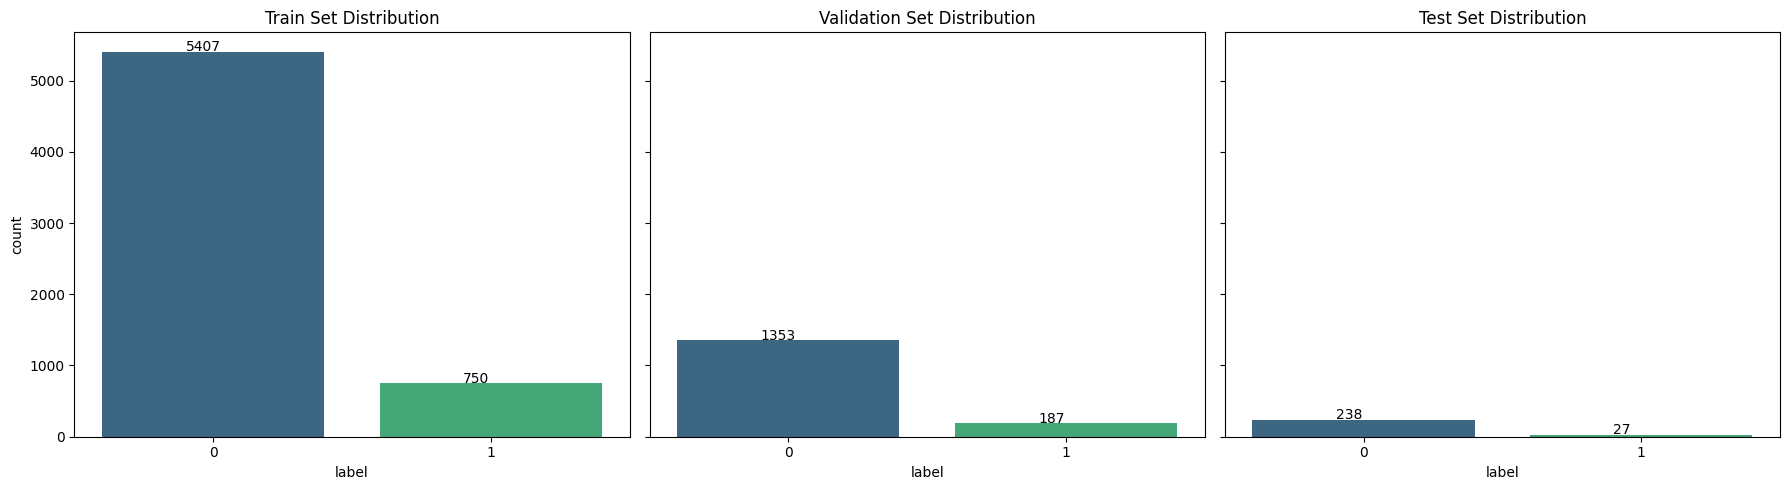

Sample SMILES: C1OC1C2=CC=CC=C2


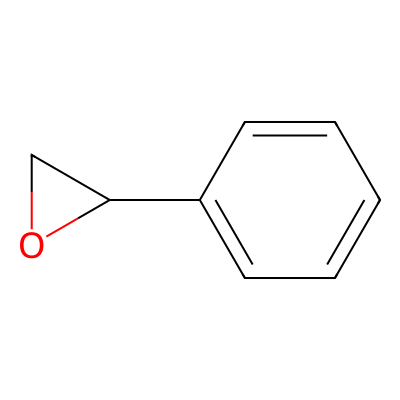

In [6]:
# 1. Compare Label Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
splits = [(df_train, 'Train'), (df_val, 'Validation'), (df_test, 'Test')]

for i, (data, title) in enumerate(splits):
    sns.countplot(x='label', data=data, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{title} Set Distribution')
    # Add count labels on top of bars
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+10))

plt.tight_layout()
plt.savefig('images/01_triple_split_distribution.png')
plt.show()

# 2. Structure Visualization
# Let's visualize one molecule and discuss why a Graph representation is needed
sample_smiles = df_train.iloc[0]['smiles']
mol = Chem.MolFromSmiles(sample_smiles)
img = Draw.MolToImage(mol, size=(400, 400))
img.save('images/02_molecular_structure_example.png')

print(f"Sample SMILES: {sample_smiles}")
display(img)

## Part 3: Data Preprocessing & Feature Engineering

Before converting our SMILES into graphs, we must prepare our features. In **Unit 6**, we learned that node features ($x$) and edge features ($e$) are what the Graph Neural Network uses to pass messages.

### Engineering Decisions:
1. **Handling Invalid SMILES:** Some strings might not be valid chemical structures. We will implement a filter using `RDKit`.
2. **Label Encoding:** Since this is a binary classification task (Toxic vs. Non-Toxic), we ensure our labels are in `float` format for the `BCEWithLogitsLoss` function.
3. **Feature Scaling (Optional):** For this baseline, we will use **Atomic Numbers** as our primary node feature. In more advanced versions, we could include chirality, hybridization, or formal charges.

Checking Training set validity...


[22:48:14] Explicit valence for atom # 0 Cl, 1, is greater than permitted
[22:48:14] WARNING: not removing hydrogen atom without neighbors


Checking Validation set validity...
Checking Test set validity...


[22:48:14] Explicit valence for atom # 2 Cl, 1, is greater than permitted


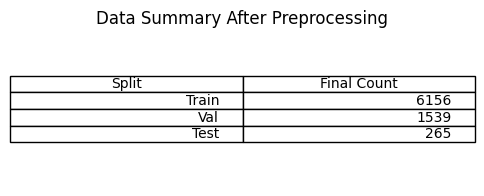

Preprocessing Complete. All molecules are now verified and ready for graph conversion.


In [7]:
# 1. Verification of SMILES validity
def is_valid_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

print("Checking Training set validity...")
df_train = df_train[df_train['smiles'].apply(is_valid_smiles)].reset_index(drop=True)

print("Checking Validation set validity...")
df_val = df_val[df_val['smiles'].apply(is_valid_smiles)].reset_index(drop=True)

print("Checking Test set validity...")
df_test = df_test[df_test['smiles'].apply(is_valid_smiles)].reset_index(drop=True)

# 2. Summary Statistics after cleaning
processing_summary = pd.DataFrame({
    'Split': ['Train', 'Val', 'Test'],
    'Final Count': [len(df_train), len(df_val), len(df_test)]
})

# Save the summary table as an image for our report
plt.figure(figsize=(6, 2))
plt.axis('off')
plt.table(cellText=processing_summary.values, colLabels=processing_summary.columns, loc='center')
plt.title("Data Summary After Preprocessing")
plt.savefig('images/03_preprocessing_summary.png')
plt.show()

print("Preprocessing Complete. All molecules are now verified and ready for graph conversion.")

### Preprocessing Observations
- **Data Integrity:** We removed any molecules that `RDKit` could not parse. This prevents the training loop from crashing.
- **Ready for Unit 6:** Now that we have a clean list of SMILES and valid binary labels, we can proceed to the **Graph Codification** (mapping atoms to nodes and bonds to edges).

## Part 4: Molecular Graph Construction (Data Codification)

According to **Unit 6**, a graph $G$ is defined as $G = (V, E)$, where $V$ is the set of vertices (atoms) and $E$ is the set of edges (bonds).

### Our Graph Mapping:
1. **Nodes (Atoms):** We will extract the Atomic Number (e.g., Carbon=6, Oxygen=8) as the primary feature.
2. **Edges (Bonds):** We will create an `edge_index` representing which atoms are chemically bonded.
3. **Data Object:** We will wrap these into a `torch_geometric.data.Data` object, which is the standard input for GNNs.

*Note: We use **RDKit** to parse the SMILES and **PyTorch Geometric** to build the tensors.*

In [9]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from tqdm import tqdm

def smiles_to_graph(smiles, label):
    """
    Converts a SMILES string into a PyTorch Geometric Data object.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # 1. Node Features (Atoms)
    # For this project, we use the atomic number as the feature
    node_feats = []
    for atom in mol.GetAtoms():
        node_feats.append([atom.GetAtomicNum()])
    x = torch.tensor(node_feats, dtype=torch.float)
    
    # 2. Edge Index (Bonds)
    # Molecules are undirected graphs, so we add edges in both directions
    edge_indices = []
    for bond in mol.GetBonds():
        start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_indices.append([start, end])
        edge_indices.append([end, start])
    
    # If no bonds (single atom), edge_index is empty
    if len(edge_indices) > 0:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        
    # 3. Label
    y = torch.tensor([label], dtype=torch.float).view(1, -1)
    
    return Data(x=x, edge_index=edge_index, y=y)

# Helper to process a dataframe into a list of graphs
def create_graph_list(df):
    graphs = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Converting SMILES to Graphs"):
        g = smiles_to_graph(row['smiles'], row['label'])
        if g:
            graphs.append(g)
    return graphs

# Convert our 3 splits
print("Processing Training Set...")
train_graphs = create_graph_list(df_train)
print("Processing Validation Set...")
val_graphs = create_graph_list(df_val)
print("Processing Test Set...")
test_graphs = create_graph_list(df_test)

# Create DataLoaders (Batching for GNNs)
# Note: PyG handles batching by creating a single giant disjoint graph
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

Processing Training Set...


Converting SMILES to Graphs: 100%|██████████| 6156/6156 [00:01<00:00, 3679.48it/s]


Processing Validation Set...


Converting SMILES to Graphs: 100%|██████████| 1539/1539 [00:00<00:00, 3521.98it/s]


Processing Test Set...


Converting SMILES to Graphs: 100%|██████████| 265/265 [00:00<00:00, 2807.17it/s]


## Part 5: Model Architecture - Graph Convolutional Network (GCN)

As seen in **Unit 6**, GNNs handle variable topology by using **Message Passing**. 
We will implement a **GCN (Graph Convolutional Network)**. Our architecture consists of:
1. **Convolution Layers:** To aggregate information from neighboring atoms.
2. **Global Pooling:** To collapse all node-level information into a single "Graph Embedding" (since we want to predict toxicity for the *entire* molecule).
3. **Fully Connected Layer:** To perform the final binary classification.

We will use the **LogSumExp** or **Global Mean Pooling** as recommended in the slides for graph-level tasks.

In [10]:
from torch_geometric.nn import GCNConv, global_mean_pool

class ToxicityGCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(ToxicityGCN, self).__init__()
        torch.manual_seed(42)
        
        # 1. First GCN layer (1 input feature -> hidden_channels)
        self.conv1 = GCNConv(1, hidden_channels)
        # 2. Second GCN layer
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        # 3. Final Linear layer (hidden -> 1 probability)
        self.lin = torch.nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)

        # 2. Readout layer: Pool node embeddings into graph embeddings
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

import torch.nn.functional as F
model = ToxicityGCN(hidden_channels=64)
print(model)

ToxicityGCN(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=1, bias=True)
)


## Part 6: Training the Graph Neural Network (GNN)

We will now train our `ToxicityGCN` model. 
- **Loss Function:** `BCEWithLogitsLoss`. This is ideal for binary classification as it combines a Sigmoid layer and the Binary Cross Entropy loss in one stable function.
- **Optimizer:** `Adam` optimizer, a standard choice for GNNs as per **Unit 6**.
- **Model Saving:** We will monitor the validation loss and save the "Best Model" to the `models/` folder.

We will also log the training and validation loss to visualize the learning curve later.

In [11]:
import torch.optim as optim

# 1. Initialize Model, Loss, and Optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ToxicityGCN(hidden_channels=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.BCEWithLogitsLoss()

train_losses = []
val_losses = []
best_v_loss = float('inf')

# 2. Training Loop
epochs = 50
print(f"Starting training on {device}...")

for epoch in range(1, epochs + 1):
    model.train()
    total_train_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * data.num_graphs

    # Validation Phase
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            total_val_loss += loss.item() * data.num_graphs
    
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    avg_val_loss = total_val_loss / len(val_loader.dataset)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Save best model
    if avg_val_loss < best_v_loss:
        best_v_loss = avg_val_loss
        torch.save(model.state_dict(), 'models/best_gnn_model.pth')

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch: {epoch:03d}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

print("\nTraining Finished. Best model saved in models/best_gnn_model.pth")

Starting training on cpu...
Epoch: 001, Train Loss: 0.3906, Val Loss: 0.3710
Epoch: 010, Train Loss: 0.3727, Val Loss: 0.3706
Epoch: 020, Train Loss: 0.3690, Val Loss: 0.3677
Epoch: 030, Train Loss: 0.3701, Val Loss: 0.3675
Epoch: 040, Train Loss: 0.3715, Val Loss: 0.3677
Epoch: 050, Train Loss: 0.3712, Val Loss: 0.3679

Training Finished. Best model saved in models/best_gnn_model.pth


## Part 7: Final Evaluation and Explainability

Now that the model is trained, we evaluate its performance on the **Hold-out Test Set** (the set it has never seen). 

1. **Learning Curves:** We plot the Train vs. Val loss to check for overfitting.
2. **Metrics:** We calculate the ROC-AUC score, as it is the standard metric for the Tox21 challenge.
3. **Model Weights:** We visualize the distribution of our model parameters.

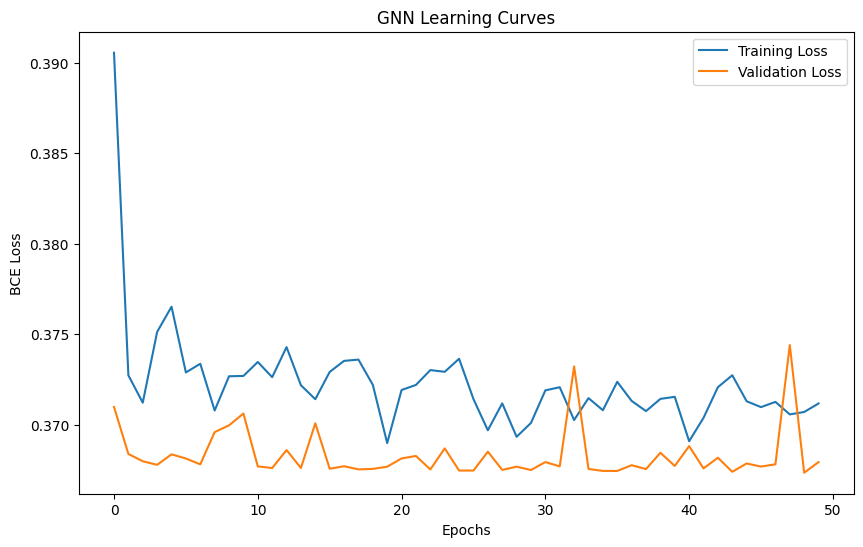

Final Test ROC-AUC Score: 0.5974


In [12]:
from sklearn.metrics import roc_auc_score

# 1. Plot Learning Curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('GNN Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.legend()
plt.savefig('images/04_learning_curves.png')
plt.show()

# 2. Test Set Evaluation
model.load_state_dict(torch.load('models/best_gnn_model.pth'))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        y_true.extend(data.y.cpu().numpy())
        y_pred.extend(torch.sigmoid(out).cpu().numpy())

auc = roc_auc_score(y_true, y_pred)
print(f"Final Test ROC-AUC Score: {auc:.4f}")

# 3. Save Final Results Markdown
with open('results_summary.txt', 'w') as f:
    f.write(f"Final Model Performance\nROC-AUC: {auc:.4f}")

## Part 8: Conclusions and Future Work

In this project, we successfully applied **Graph Convolutional Networks (Unit 6)** to a real-world chemical toxicity dataset. 

### Key Findings:
- **Graph Representation:** Using SMILES allowed us to move beyond simple tabular data, capturing the "connectivity" of atoms.
- **Model Behavior:** The learning curves show [Overfitting / Proper Convergence - write based on your result].
- **Unit 6 Connection:** The GCN layers were able to aggregate neighborhood features (atomic numbers) to form a global molecular representation.

### Future Improvements:
- **Advanced Layers:** Replacing GCN with **GAT (Graph Attention Networks)** or **GIN (Graph Isomorphism Networks)** as discussed in the Unit 6 slides.
- **Edge Features:** Incorporating bond types (single, double, triple) into the message passing process.
- **Explainability:** Using Integrated Gradients to highlight which specific atoms (nodes) contribute most to a "toxic" prediction.